In [1]:
from data_utils import index_segmentations_df
import pandas as pd
from pathlib import Path

In [2]:
path_df = index_segmentations_df(
    r"C:\Users\chris\Desktop\University\Thesis\AnnotationsData\Segmentations", 
    mask_name = 'calculated_masks'
)

mask_quality_df = pd.read_csv('mask_quality_summary.csv')
mask_quality_df = mask_quality_df[['image_path', 'mask_quality']]


mask_quality_df["image_path"] = mask_quality_df["image_path"].apply(Path)

path_df = path_df.merge(mask_quality_df, on = 'image_path', how = 'inner')
print(path_df.columns)

# Only segment the entire cell ie. not just the SOMA
path_df = path_df[path_df['class'] == 'MG_whole']
# Remove all bad annotations
path_df = path_df[~path_df['mask_quality'].isin(['bad', 'bad_image_quality', 'disagree', 'medium'])]

# path_df = path_df.merg(mask_quality_df, on = )
# Only take first 100 for now to train fast
# path_df = path_df.head(320)
print(len(path_df), "annotation pairs found")

Index(['scan', 'class', 'image_path', 'mask_path', 'mask_quality'], dtype='object')
654 annotation pairs found


In [3]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    path_df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(len(train_df), len(test_df))


523 131


In [4]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class SegmentationDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        mask_path = self.df.loc[idx, "mask_path"]

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = np.array(image)
        mask = np.array(mask)

        # Normalize mask to {0,1}
        mask = (mask > 0).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        image = image.float() / 255.0
        mask = mask.unsqueeze(0)  # (1, H, W)

        return image, mask


In [5]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_tfms = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    ToTensorV2()
])

test_tfms = A.Compose([
    A.Resize(256, 256),
    ToTensorV2()
])


In [6]:
from torch.utils.data import DataLoader

train_ds = SegmentationDataset(train_df, train_tfms)
test_ds  = SegmentationDataset(test_df, test_tfms)
# train_ds = SegmentationDataset(train_df)
# test_ds  = SegmentationDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0)


In [7]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = DoubleConv(3, 64)
        self.d2 = DoubleConv(64, 128)
        self.d3 = DoubleConv(128, 256)

        self.u2 = DoubleConv(256 + 128, 128)
        self.u1 = DoubleConv(128 + 64, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        c1 = self.d1(x)
        c2 = self.d2(F.max_pool2d(c1, 2))
        c3 = self.d3(F.max_pool2d(c2, 2))

        u2 = F.interpolate(c3, scale_factor=2, mode="bilinear", align_corners=False)
        u2 = self.u2(torch.cat([u2, c2], dim=1))

        u1 = F.interpolate(u2, scale_factor=2, mode="bilinear", align_corners=False)
        u1 = self.u1(torch.cat([u1, c1], dim=1))

        return self.out(u1)


In [8]:
def dice_score(pred, target, eps=1e-6):
    pred = (pred > 0.5).float()
    inter = (pred * target).sum()
    union = pred.sum() + target.sum()
    return (2 * inter + eps) / (union + eps)

def iou_score(pred, target, eps=1e-6):
    pred = (pred > 0.5).float()
    inter = (pred * target).sum()
    union = pred.sum() + target.sum() - inter
    return (inter + eps) / (union + eps)


In [9]:
class DiceLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        inter = (probs * targets).sum(dim=1)
        union = probs.sum(dim=1) + targets.sum(dim=1)

        dice = (2 * inter + self.eps) / (union + self.eps)
        return 1 - dice.mean()


In [10]:
def total_variation_loss(mask):
    return torch.mean(torch.abs(mask[:, :, :, :-1] - mask[:, :, :, 1:])) + \
           torch.mean(torch.abs(mask[:, :, :-1, :] - mask[:, :, 1:, :]))


In [17]:
criterion = nn.BCEWithLogitsLoss()
# criterion = DiceLoss()

device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)



@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    dice_list, iou_list = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        probs = torch.sigmoid(logits)

        dice_list.append(dice_score(probs, y).item())
        iou_list.append(iou_score(probs, y).item())

    return {
        "dice": sum(dice_list) / len(dice_list),
        "iou": sum(iou_list) / len(iou_list),
    }


In [18]:
import matplotlib.pyplot as plt
import torch

@torch.no_grad()
def visualize_predictions(
    model,
    loader,
    device,
    num_samples=3,
    threshold=0.5
):
    model.eval()

    x, y = next(iter(loader))
    x, y = x.to(device), y.to(device)

    logits = model(x)
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    for i in range(min(num_samples, x.size(0))):
        img = x[i].cpu().permute(1, 2, 0)
        gt  = y[i, 0].cpu()
        pr  = preds[i, 0].cpu()

        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(img)
        plt.title("Input image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(gt, cmap="gray")
        plt.title("Ground truth")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pr, cmap="gray")
        plt.title("Prediction")
        plt.axis("off")

        plt.tight_layout()
        plt.show()


In [19]:
from datetime import datetime
import os
import torch


def save_model_with_timestamp(model):

    # Create output directory
    save_dir = "checkpoints"
    os.makedirs(save_dir, exist_ok=True)

    # Timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Filename
    model_path = os.path.join(
        save_dir,
        f"unet_MG_whole_{timestamp}.pth"
    )

    # Save weights
    torch.save(model.state_dict(), model_path)

    print(f"Model saved to: {model_path}")


In [20]:
from tqdm import trange, tqdm

epochs = 5

for epoch in trange(epochs, desc="Training", unit="epoch"):
    train_loss = train_epoch(model, train_loader)
    metrics = evaluate(model, test_loader)

    tqdm.write(
        f"Epoch {epoch:03d} | "
        f"Loss: {train_loss:.4f} | "
        f"Dice: {metrics['dice']:.4f} | "
        f"IoU: {metrics['iou']:.4f}"
    )

# Save model
save_model_with_timestamp(model)

# Visualize predictions




Training:  20%|██        | 1/5 [15:30<1:02:02, 930.69s/epoch]

Epoch 000 | Loss: 0.3330 | Dice: 0.8222 | IoU: 0.6988


Training:  20%|██        | 1/5 [21:08<1:24:34, 1268.55s/epoch]


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\chris\\Desktop\\University\\Thesis\\AnnotationsData\\Segmentations\\images\\2011-104_Iba1_Tp_B2_AD.vsi - 20x_BF_01\\MG_whole\\ann-104__x-34324_y-29107_w-182_h-133__ds-1.png'

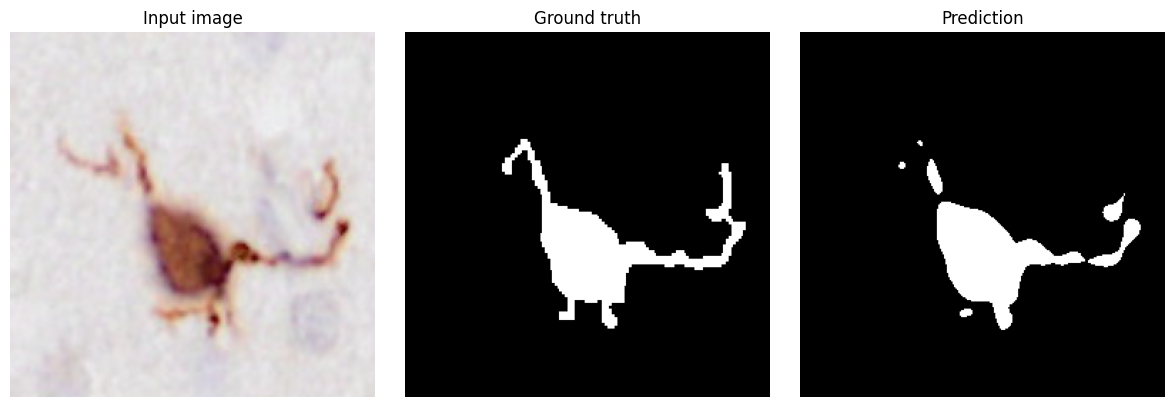

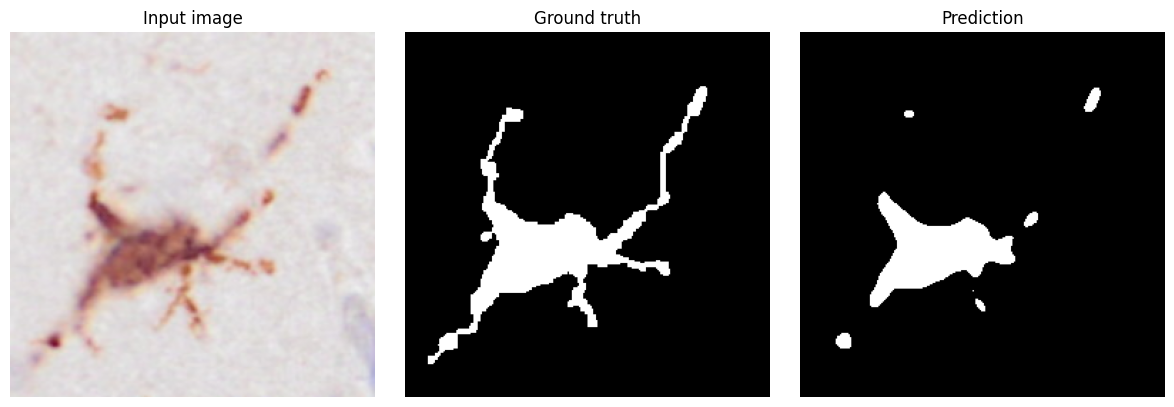

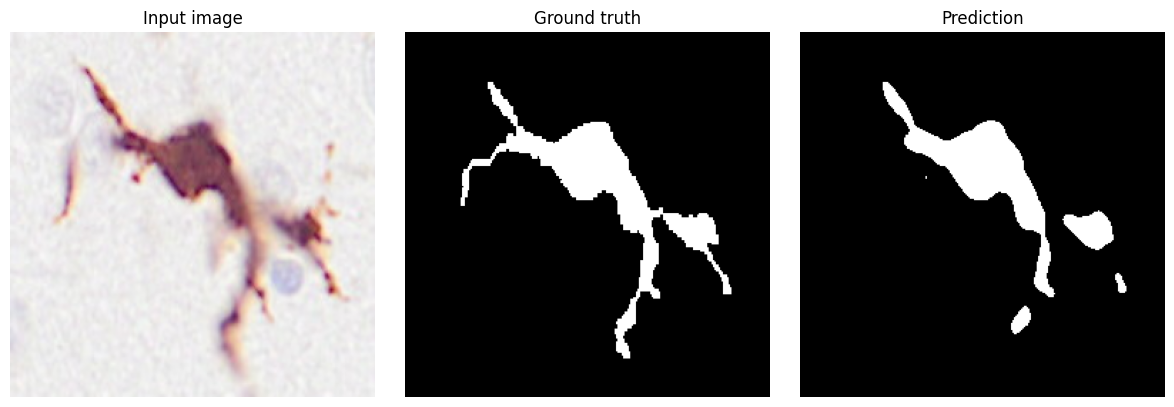

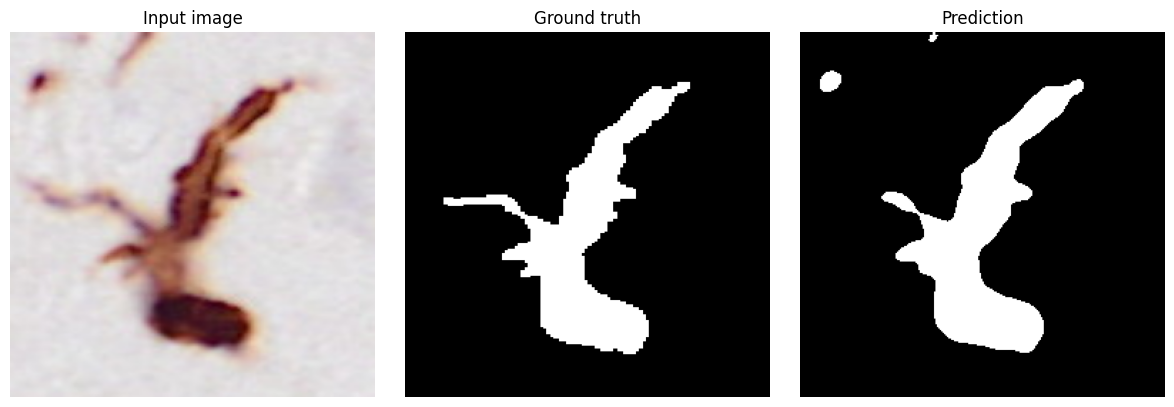

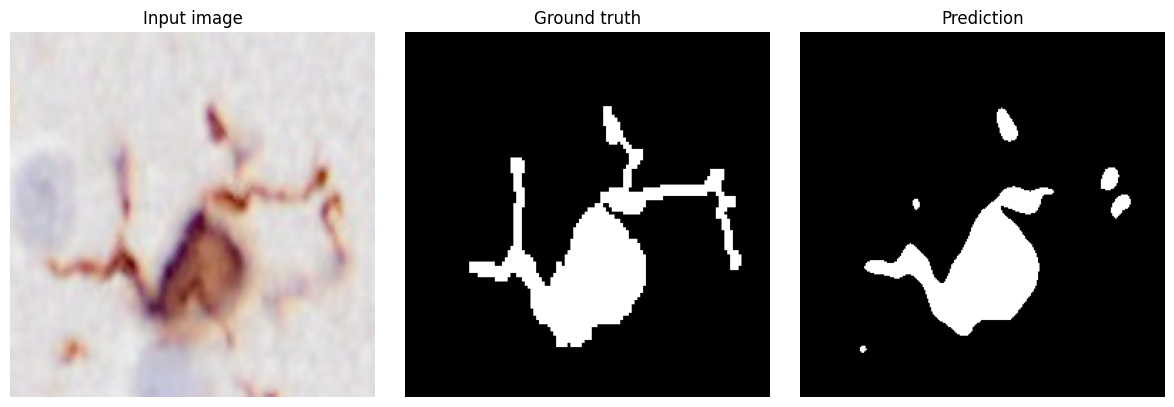

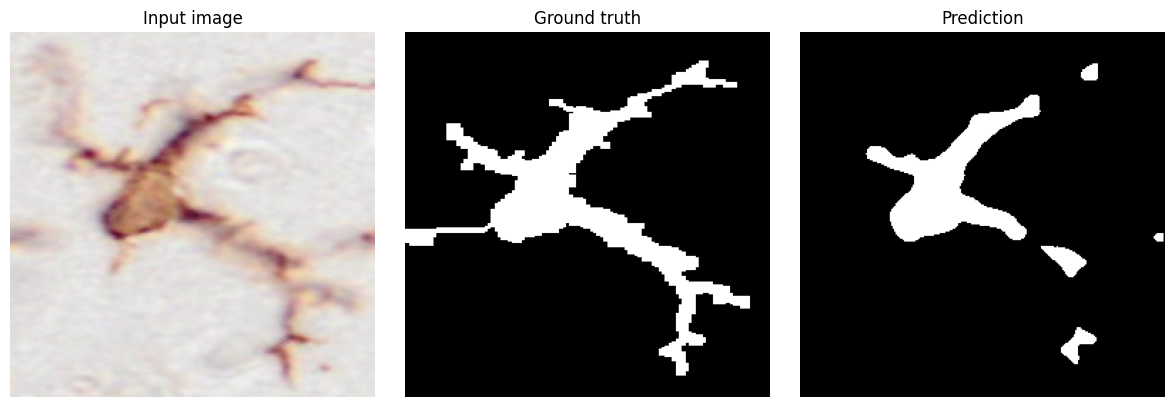

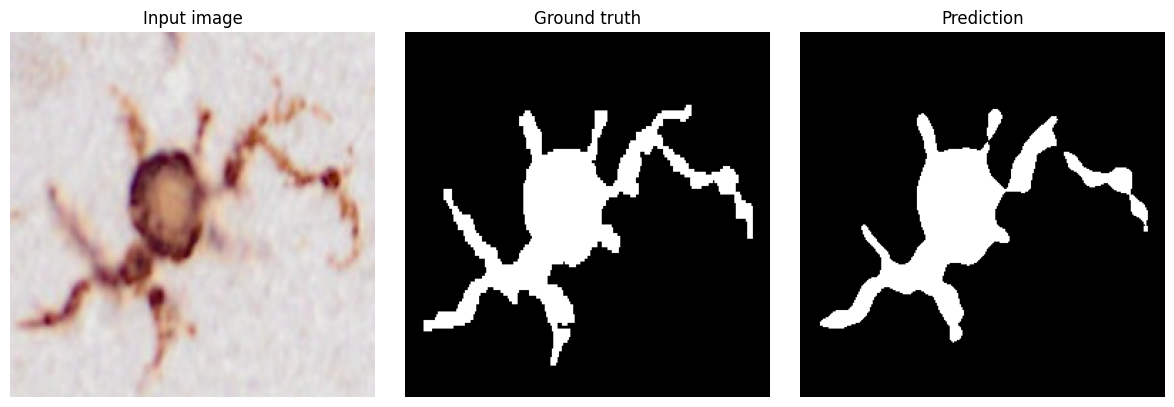

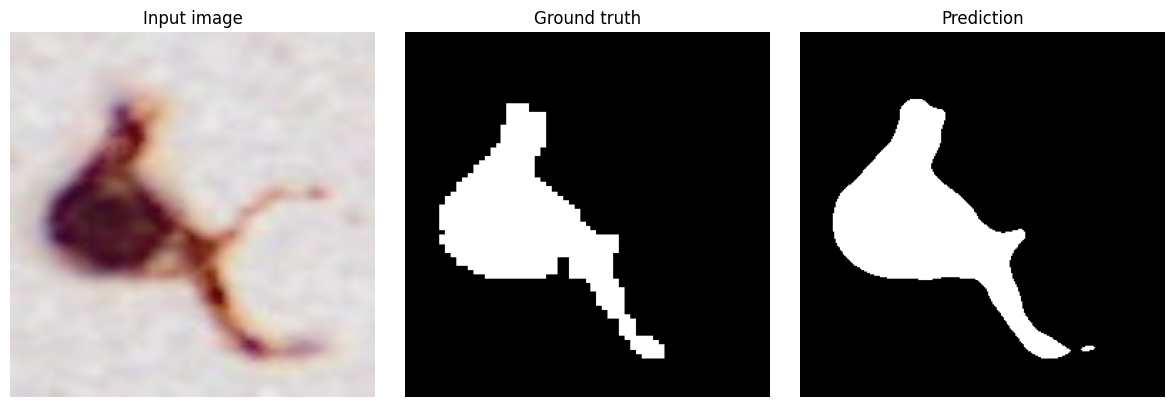

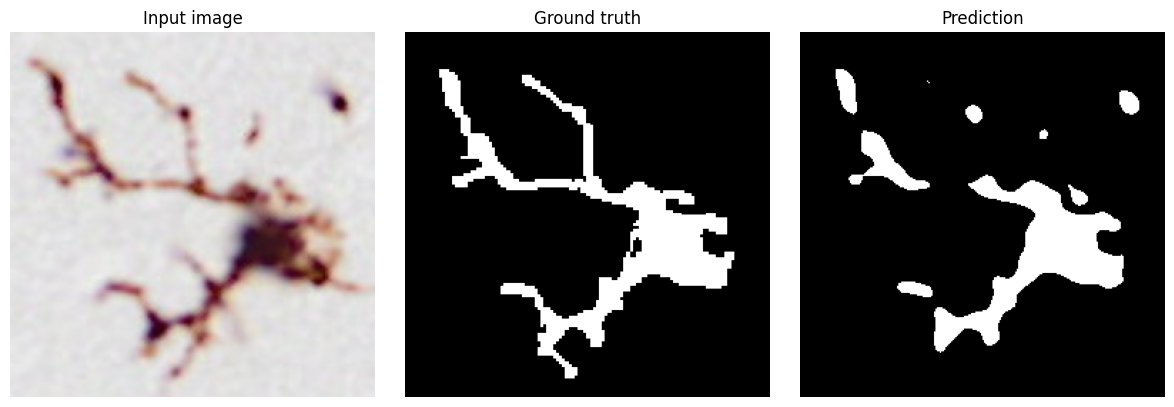

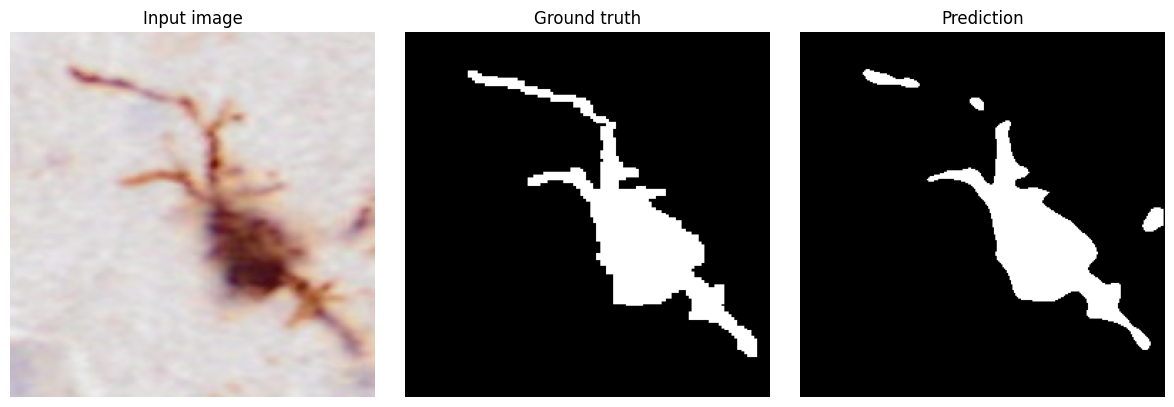

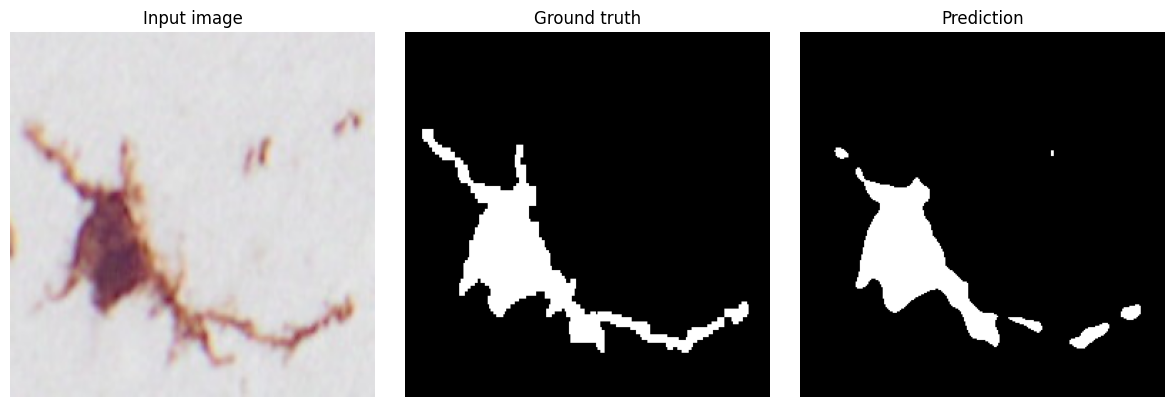

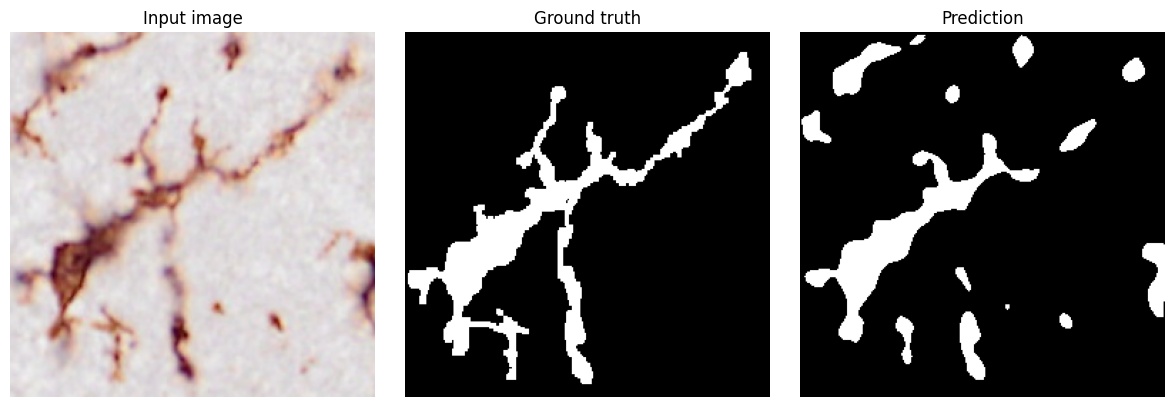

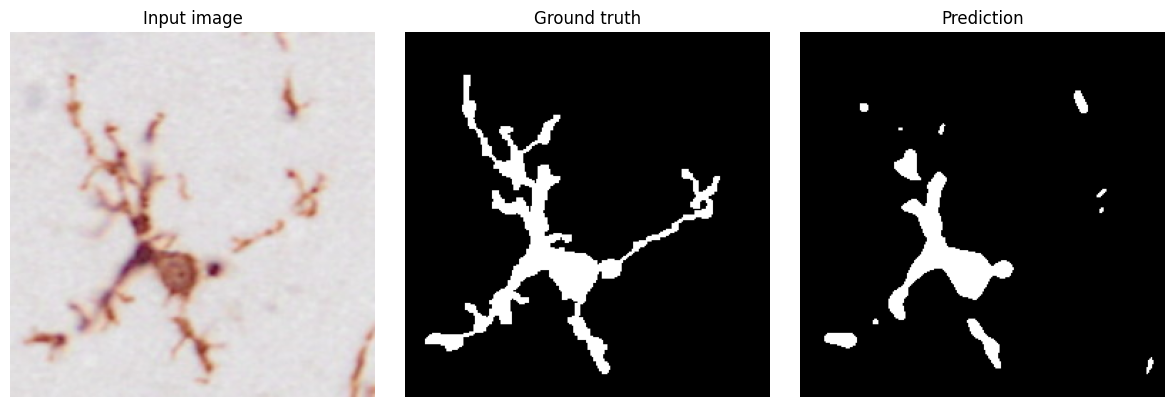

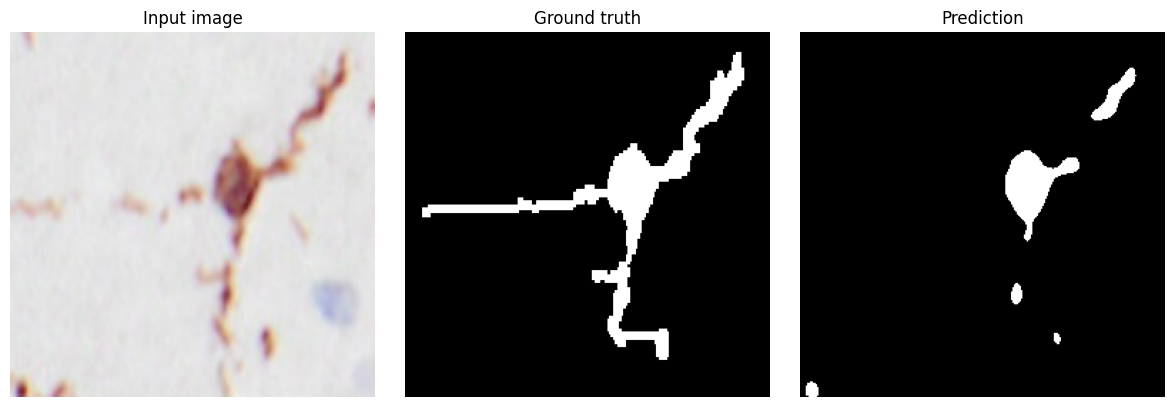

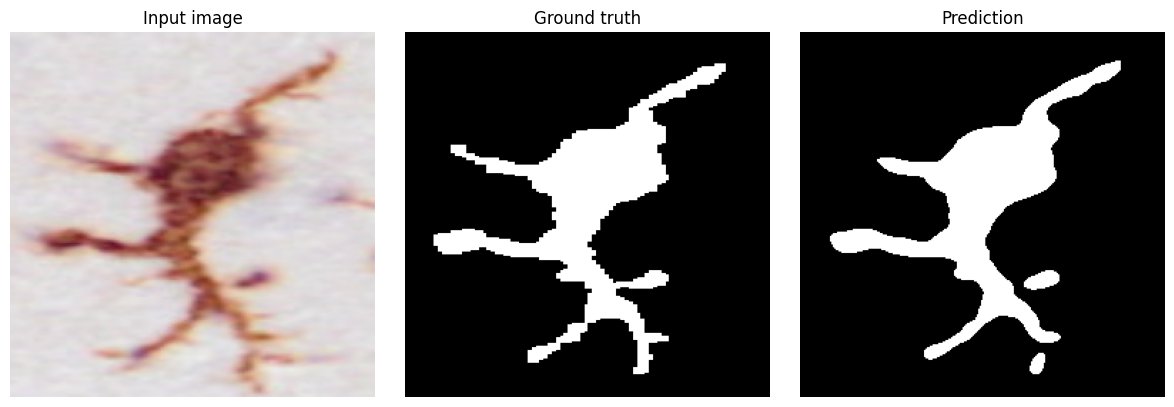

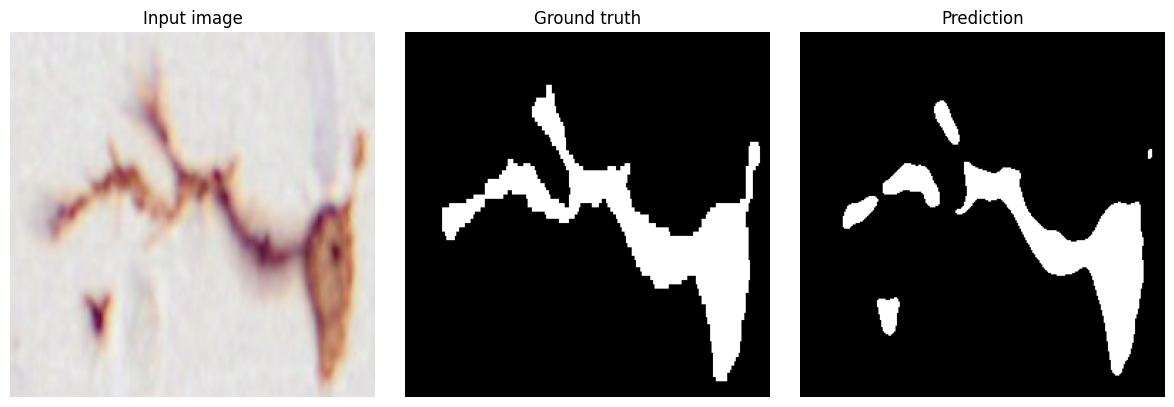

In [15]:
visualize_predictions(model, test_loader, device, num_samples=20, threshold=0.5)

In [ ]:
# model = UNet().to(device)
# model.load_state_dict(torch.load(model_path, map_location=device))
# model.eval()
